# SB3 DQN-CNN on highway-v0
Mohammed SBAIHI

This notebook benchmarks Stable-Baselines3 DQN with CnnPolicy on the extension environment config I used in CNN-DDQN.

In [ ]:
# the following code is a simple fix because I am using a headless VM with no sound card
# and it keeps throwing errors related to ALSA and SDL audio drivers.
import os
from pathlib import Path

Path("/tmp/xdg-runtime").mkdir(parents=True, exist_ok=True)
os.chmod("/tmp/xdg-runtime", 0o700)
os.environ["XDG_RUNTIME_DIR"] = "/tmp/xdg-runtime"

Path("/tmp/asound.conf").write_text(
    "pcm.!default { type null }\nctl.!default { type null }\n",
    encoding="utf-8",
)
os.environ["ALSA_CONFIG_PATH"] = "/tmp/asound.conf"
os.environ["SDL_AUDIODRIVER"] = "dummy"

In [2]:
import sys
import torch

print(sys.executable)
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

/usr/local/bin/python
2.8.0+cu128 12.8 True
NVIDIA RTX A4000


In [ ]:
import csv
import os
import json
import time
import random
import statistics as stats
from dataclasses import dataclass, asdict

import gymnasium as gym
import highway_env
import matplotlib.pyplot as plt
import numpy as np
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, CallbackList, CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor

from extension_cnn_config import CNN_DDQN_CONFIG, CNN_DDQN_ENV_ID

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available on this system. \n" \
    "I ran my experiments on a machine with a GPU, \n" \
    "so I recommend running this nb on a GPU where CUDA is available.")

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True
if hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda")
print("CUDA available:", device)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


CUDA available: cuda


In [4]:
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
RUN_DIR = os.path.join("real_checkpoints_sb3_dqn", f"run_{RUN_ID}")
os.makedirs(RUN_DIR, exist_ok=True)
print("run dir:", RUN_DIR)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def to_chw_stack(observation: np.ndarray) -> np.ndarray:
    """Normalize highway grayscale stack to CHW=(4,84,84)."""
    obs = np.asarray(observation)

    if obs.shape == (4, 84, 84):
        chw = obs
    elif obs.shape == (84, 84, 4):
        chw = np.transpose(obs, (2, 0, 1))
    elif obs.shape == (84, 4, 84):
        chw = np.transpose(obs, (1, 0, 2))
    else:
        raise ValueError(f"Unexpected observation shape: {obs.shape}")

    return chw

class CnnObsWrapper(gym.ObservationWrapper):
    """Convert grayscale stack observations to CHW uint8 for SB3 CnnPolicy."""

    def __init__(self, env: gym.Env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=0,
            high=255,
            shape=(4, 84, 84),
            dtype=np.uint8,
        )

    def observation(self, observation):
        obs = to_chw_stack(observation)

        if obs.dtype != np.uint8:
            max_val = float(np.max(obs)) if obs.size else 0.0
            if max_val <= 1.0:
                obs = obs * 255.0
            obs = np.clip(obs, 0.0, 255.0).astype(np.uint8)

        return obs

def make_env(seed: int, render: bool = False, for_sb3: bool = False) -> gym.Env:
    config = dict(CNN_DDQN_CONFIG)
    render_mode = None
    if render:
        config["offscreen_rendering"] = True
        render_mode = "rgb_array"

    env = gym.make(CNN_DDQN_ENV_ID, config=config, render_mode=render_mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

    if for_sb3:
        env = CnnObsWrapper(env)

    return env

run dir: real_checkpoints_sb3_dqn/run_20260413-132955


In [5]:
@dataclass
class Sb3DqnCnnConfig:
    total_timesteps: int = 22_500

    # replay buffer
    buffer_size: int = 100_000
    learning_starts: int = 1_000
    batch_size: int = 64

    # discounting and target network
    gamma: float = 0.99
    target_update_interval: int = 1_000

    # epsilon schedule (linear in SB3)
    exploration_initial_eps: float = 1.0
    exploration_final_eps: float = 0.05
    exploration_fraction: float = 0.95

    # optimization
    learning_rate: float = 1e-4
    train_freq: int = 4
    gradient_steps: int = 1

    # evaluation
    eval_episodes: int = 50
    eval_freq_steps: int = 5_000
    checkpoint_every_steps: int = 10_000

observation shape: (4, 84, 84) dtype: uint8


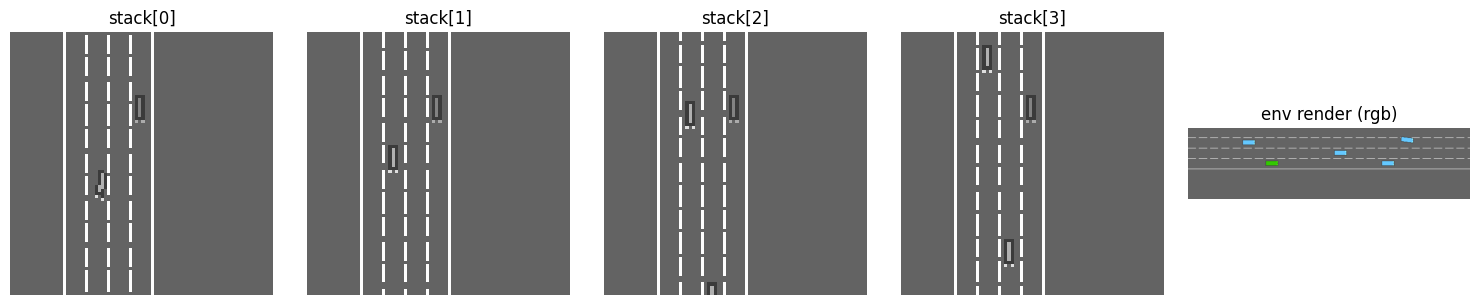

In [ ]:
viz_seed = 0
viz_env = make_env(viz_seed, render=True, for_sb3=False)
obs, _ = viz_env.reset(seed=viz_seed)

steps_since_reset = 0
while steps_since_reset < 4:
    action = viz_env.action_space.sample()
    obs, _, terminated, truncated, _ = viz_env.step(action)
    if terminated or truncated:
        obs, _ = viz_env.reset(seed=viz_seed)
        steps_since_reset = 0
    else:
        steps_since_reset += 1

stacked = to_chw_stack(obs)

print("observation shape:", stacked.shape, "dtype:", stacked.dtype)
rgb_frame = viz_env.render()
vmax = 1.0 if float(stacked.max()) <= 1.0 else 255.0

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(4):
    axes[i].imshow(stacked[i], cmap="gray", vmin=0.0, vmax=vmax)
    axes[i].set_title(f"stack[{i}]")
    axes[i].axis("off")

axes[4].imshow(rgb_frame)
axes[4].set_title("env render (rgb)")
axes[4].axis("off")

plt.tight_layout()
plt.show()
viz_env.close()

In [ ]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

def plot_training_curve_from_monitor(monitor_csv_path: str, title: str, save_path: str, show: bool = True) -> None:
    import csv

    if not os.path.exists(monitor_csv_path):
        print(f"monitor file not found, skipping curve: {monitor_csv_path}")
        return

    rewards = []
    with open(monitor_csv_path, "r", encoding="utf-8") as f:
        _ = f.readline()  # monitor metadata header line (starts with '#')
        reader = csv.DictReader(f)
        for row in reader:
            if "r" in row:
                rewards.append(float(row["r"]))

    if not rewards:
        print("no episode rewards found in monitor file, skipping curve")
        return

    xs = np.arange(1, len(rewards) + 1)
    ys = np.asarray(rewards, dtype=np.float32)

    plt.figure(figsize=(10, 4))
    plt.plot(xs, ys, alpha=0.35, label="episode reward")

    if len(ys) >= 100:
        kernel = np.ones(100, dtype=np.float32) / 100.0
        ma = np.convolve(ys, kernel, mode="valid")
        ma_xs = np.arange(100, len(ys) + 1)
        plt.plot(ma_xs, ma, linewidth=2, label="100-episode moving average")

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    if show:
        plt.show()
    else:
        plt.close()


class EpisodeCsvCallback(BaseCallback):

    def __init__(self, csv_path: str, verbose: int = 0):
        super().__init__(verbose)
        self.csv_path = csv_path
        self.episode_count = 0
        self._csv_file = None
        self._csv_writer = None

    def _on_training_start(self) -> None:
        is_new = not os.path.exists(self.csv_path)
        self._csv_file = open(self.csv_path, "a", newline="", encoding="utf-8")
        self._csv_writer = csv.writer(self._csv_file)
        if is_new:
            self._csv_writer.writerow(["episode", "reward", "crashed", "length"])
            self._csv_file.flush()

    def _on_step(self) -> bool:
        dones = self.locals.get("dones", [])
        infos = self.locals.get("infos", [])
        for done, info in zip(dones, infos):
            if done:
                ep_info = info.get("episode", {})
                reward = float(ep_info.get("r", 0.0))
                length = int(ep_info.get("l", 0))
                crashed = int(info.get("crashed", False))
                self.episode_count += 1
                self._csv_writer.writerow([self.episode_count, reward, crashed, length])
                self._csv_file.flush()
        return True

    def _on_training_end(self) -> None:
        if self._csv_file is not None:
            self._csv_file.close()
            self._csv_file = None


def train_one_seed(seed: int, cfg: Sb3DqnCnnConfig) -> dict:
    set_seed(seed)

    run_seed_dir = os.path.join(RUN_DIR, f"seed_{seed}")
    os.makedirs(run_seed_dir, exist_ok=True)

    monitor_path = os.path.join(run_seed_dir, "train.monitor.csv")
    train_env = Monitor(
        make_env(seed=seed, render=False, for_sb3=True),
        filename=monitor_path,
    )
    eval_env = Monitor(make_env(seed=seed + 10_000, render=False, for_sb3=True))

    try:
        model = DQN(
            policy="CnnPolicy",
            env=train_env,
            learning_rate=cfg.learning_rate,
            buffer_size=cfg.buffer_size,
            learning_starts=cfg.learning_starts,
            batch_size=cfg.batch_size,
            gamma=cfg.gamma,
            train_freq=cfg.train_freq,
            gradient_steps=cfg.gradient_steps,
            target_update_interval=cfg.target_update_interval,
            exploration_fraction=cfg.exploration_fraction,
            exploration_initial_eps=cfg.exploration_initial_eps,
            exploration_final_eps=cfg.exploration_final_eps,
            tensorboard_log=None,
            device="cuda",
            seed=seed,
            verbose=1,
        )

        checkpoint_cb = CheckpointCallback(
            save_freq=max(cfg.checkpoint_every_steps, 1),
            save_path=os.path.join(run_seed_dir, "checkpoints"),
            name_prefix="dqn_cnn",
        )

        eval_cb = EvalCallback(
            eval_env=eval_env,
            best_model_save_path=os.path.join(run_seed_dir, "best_model"),
            log_path=os.path.join(run_seed_dir, "eval_logs"),
            eval_freq=max(cfg.eval_freq_steps, 1),
            n_eval_episodes=cfg.eval_episodes,
            deterministic=True,
            render=False,
        )

        csv_cb = EpisodeCsvCallback(
            csv_path=os.path.join(run_seed_dir, "training_stats.csv"),
        )

        callbacks = CallbackList([checkpoint_cb, eval_cb, csv_cb])
        model.learn(total_timesteps=cfg.total_timesteps, callback=callbacks, progress_bar=False, log_interval=10)

        curve_path = os.path.join(run_seed_dir, "training_curve.png")
        plot_training_curve_from_monitor(
            monitor_csv_path=monitor_path,
            title=f"SB3 DQN-CNN Training | seed={seed}",
            save_path=curve_path,
            show=True,
        )

        final_model_base = os.path.join(run_seed_dir, "final_model")
        model.save(final_model_base)

        best_model_path = os.path.join(run_seed_dir, "best_model", "best_model.zip")
        final_model_path = final_model_base + ".zip"
        selected_model_path = best_model_path if os.path.exists(best_model_path) else final_model_path

        return {
            "seed": seed,
            "run_seed_dir": run_seed_dir,
            "selected_model_path": selected_model_path,
            "best_model_path": best_model_path,
            "final_model_path": final_model_path,
            "curve_path": curve_path,
        }
    finally:
        train_env.close()
        eval_env.close()

def evaluate_saved_model(model_path: str, seed: int, n_episodes: int) -> dict:
    model = DQN.load(model_path, device="cuda")
    env = make_env(seed=seed + 20_000, render=False, for_sb3=True)

    rewards = []
    lengths = []
    crashes = 0

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + 30_000 + ep)
        done = False
        total_r = 0.0
        t = 0
        info = {}

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action_int = int(np.asarray(action).item())
            obs, reward, terminated, truncated, info = env.step(action_int)
            done = terminated or truncated
            total_r += float(reward)
            t += 1

        rewards.append(total_r)
        lengths.append(t)
        crashes += int(info.get("crashed", False))

    env.close()

    return {
        "mean_reward": float(stats.mean(rewards)),
        "std_reward": float(stats.stdev(rewards)) if len(rewards) > 1 else 0.0,
        "mean_length": float(stats.mean(lengths)),
        "std_length": float(stats.stdev(lengths)) if len(lengths) > 1 else 0.0,
        "crash_rate": float(crashes / n_episodes),
        "raw_eval_rewards": rewards,
    }

In [8]:
cfg = Sb3DqnCnnConfig()
SEEDS = [0, 1, 2]

if "RUN_RESULTS_BY_SEED" not in globals():
    RUN_RESULTS_BY_SEED = {}

results = []

def _refresh_results_list() -> None:
    global results
    results = [RUN_RESULTS_BY_SEED[s] for s in sorted(RUN_RESULTS_BY_SEED.keys())]

def run_one_seed(seed: int) -> dict:
    print(f"\n{'=' * 70}")
    print(f"Seed {seed}")
    print(f"{'=' * 70}")

    train_info = train_one_seed(seed=seed, cfg=cfg)
    eval_summary = evaluate_saved_model(
        model_path=train_info["selected_model_path"],
        seed=seed,
        n_episodes=cfg.eval_episodes,
    )

    result = {
        "seed": seed,
        "selected_model_path": train_info["selected_model_path"],
        **{k: v for k, v in eval_summary.items() if k != "raw_eval_rewards"},
    }

    RUN_RESULTS_BY_SEED[seed] = result
    _refresh_results_list()

    metrics_payload = {
        "label": "sb3_dqn_cnn_pixels",
        "seed": seed,
        "config": asdict(cfg),
        "selected_model_path": train_info["selected_model_path"],
        "eval": {k: v for k, v in eval_summary.items() if k != "raw_eval_rewards"},
        "raw_eval_rewards": eval_summary["raw_eval_rewards"],
    }

    metrics_path = os.path.join(train_info["run_seed_dir"], "metrics_seed.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(metrics_payload), f, indent=2)

    print(
        f"seed={seed} | mean={result['mean_reward']:.3f} +- {result['std_reward']:.3f} "
        f"| crash={result['crash_rate'] * 100:.1f}%"
    )
    return result

def aggregate_results(required_seeds: list[int] | None = None) -> dict:
    if required_seeds is None:
        required_seeds = SEEDS

    missing = [s for s in required_seeds if s not in RUN_RESULTS_BY_SEED]
    if missing:
        raise ValueError(
            f"Missing seed results for: {missing}. Run those seed cells first, then aggregate."
        )

    per_seed = [RUN_RESULTS_BY_SEED[s] for s in required_seeds]

    global results
    results = per_seed

    aggregate = {
        "mean_reward": float(stats.mean([r["mean_reward"] for r in per_seed])),
        "std_over_seeds": float(stats.stdev([r["mean_reward"] for r in per_seed])) if len(per_seed) > 1 else 0.0,
        "mean_crash_rate": float(stats.mean([r["crash_rate"] for r in per_seed])),
    }

    all_metrics = {
        "label": "sb3_dqn_cnn_pixels",
        "run_id": RUN_ID,
        "seeds": required_seeds,
        "config": asdict(cfg),
        "per_seed": per_seed,
        "aggregate": aggregate,
    }

    all_metrics_path = os.path.join(RUN_DIR, "sb3_dqn_cnn_metrics.json")
    with open(all_metrics_path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(all_metrics), f, indent=2)

    print("\nSaved metrics:", all_metrics_path)
    print("Aggregate:", aggregate)
    return all_metrics

In [9]:
seed0_result = run_one_seed(0)


Seed 0
Using cuda device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13.4     |
|    ep_rew_mean      | 10.2     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 10       |
|    fps              | 2        |
|    time_elapsed     | 46       |
|    total_timesteps  | 134      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14.3     |
|    ep_rew_mean      | 10.6     |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 2        |
|    time_elapsed     | 99       |
|    total_timesteps  | 286      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14.1     |
|    ep_rew_mean      | 10.4     |
|    exploration_rate | 0.981

KeyboardInterrupt: 

In [ ]:
seed1_result = run_one_seed(1)

In [ ]:
seed2_result = run_one_seed(2)

In [ ]:
all_metrics = aggregate_results(SEEDS)

In [ ]:
def record_video_from_model(model_path: str, seed: int, video_dir: str, episodes: int = 3, seed_offset: int = 0) -> None:
    model = DQN.load(model_path, device="cuda")

    os.makedirs(video_dir, exist_ok=True)
    env = make_env(seed=seed + seed_offset, render=True, for_sb3=True)
    env = gym.wrappers.RecordVideo(
        env,
        video_folder=video_dir,
        episode_trigger=lambda ep: ep < episodes,
        name_prefix="sb3_dqn_cnn",
    )

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + seed_offset + ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action_int = int(np.asarray(action).item())
            obs, _, terminated, truncated, _ = env.step(action_int)
            done = terminated or truncated

    env.close()
    print("videos saved to:", os.path.abspath(video_dir))

best_seed = max(results, key=lambda r: r["mean_reward"])["seed"]
best_model_path = [r["selected_model_path"] for r in results if r["seed"] == best_seed][0]
video_output_dir = os.path.join(RUN_DIR, f"videos_seed_{best_seed}")

record_video_from_model(
    model_path=best_model_path,
    seed=best_seed,
    video_dir=video_output_dir,
    episodes=3,
    seed_offset=5000,
)